# **Data Loading and Preprocessing**

In [42]:
#necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder
import time
import warnings
warnings.filterwarnings('ignore')

In [43]:
# Load the dataset
Data = pd.read_csv("/content/Groceries_dataset.csv")

In [44]:
Data

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


In [45]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [46]:
# Check for missing values
print("Missing values:")
print(Data.isnull().sum())

Missing values:
Member_number      0
Date               0
itemDescription    0
dtype: int64


In [47]:
print("\nDataset Info:")
print(f"Total rows: {len(Data)}")
print(f"Unique items: {Data['itemDescription'].nunique()}")
print(f"Unique customers: {Data['Member_number'].nunique()}")


Dataset Info:
Total rows: 38765
Unique items: 167
Unique customers: 3898


In [48]:
top5_items = Data['itemDescription'].value_counts().head(5)
print(top5_items)


itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
Name: count, dtype: int64


In [49]:
#keep duplicates(person might purchase item on the same day more than once)
print(Data.duplicated().sum())

759


In [50]:
print(Data.duplicated())

0        False
1        False
2        False
3        False
4        False
         ...  
38760    False
38761    False
38762    False
38763    False
38764    False
Length: 38765, dtype: bool


Creating Transactions

In [51]:
# Create Transaction ID
Data['Transaction'] = Data['Member_number'].astype(str) + "_" + Data['Date']

In [52]:
# Group items into transactions
transactions = Data.groupby(['Member_number', 'Date'])['itemDescription'].apply(list)

In [53]:
len(transactions)

14963

In [54]:
transactions[:10]

Member_number  Date      
1000           15-03-2015    [sausage, whole milk, semi-finished bread, yog...
               24-06-2014                    [whole milk, pastry, salty snack]
               24-07-2015                       [canned beer, misc. beverages]
               25-11-2015                          [sausage, hygiene articles]
               27-05-2015                           [soda, pickled vegetables]
1001           02-05-2015                                  [frankfurter, curd]
               07-02-2014                    [sausage, whole milk, rolls/buns]
               12-12-2014                                   [whole milk, soda]
               14-04-2015                                  [beef, white bread]
               20-01-2015              [frankfurter, soda, whipped/sour cream]
Name: itemDescription, dtype: object

Encode Transactions

In [55]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
Data = pd.DataFrame(te_ary, columns=te.columns_)


In [56]:
print("\nBinary transaction matrix(preview):")
print(Data.head())


Binary transaction matrix(preview):
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False  False    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  waffles  whipped/sour cream  w

In [57]:
Data.astype(int)

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14958,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
14959,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14960,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14961,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# **Frequent Itemset Mining**

In [58]:
frequent_itemsets = apriori(Data, min_support=0.002, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
print("\nTop Frequent Itemsets:")
print(frequent_itemsets.head(10))


Top Frequent Itemsets:
      support            itemsets
123  0.157923        (whole milk)
78   0.122101  (other vegetables)
93   0.110005        (rolls/buns)
104  0.097106              (soda)
124  0.085879            (yogurt)
94   0.069572   (root vegetables)
116  0.067767    (tropical fruit)
7    0.060683     (bottled water)
99   0.060349           (sausage)
24   0.053131      (citrus fruit)


apriori with Multiple Support thresholds

In [59]:
frequent_itemsets_by_threshold = {}

# List of support thresholds to test
support_thresholds = [0.20, 0.10, 0.05]

for threshold in support_thresholds:
    itemsets = apriori(Data, min_support=threshold, use_colnames=True)
    itemsets = itemsets.sort_values(by='support', ascending=False)
    frequent_itemsets_by_threshold[threshold] = itemsets
    print(f"\n=== Frequent Itemsets (Support ≥ {threshold}) ===")
    print(itemsets.head(10))


=== Frequent Itemsets (Support ≥ 0.2) ===
Empty DataFrame
Columns: [support, itemsets]
Index: []

=== Frequent Itemsets (Support ≥ 0.1) ===
    support            itemsets
2  0.157923        (whole milk)
0  0.122101  (other vegetables)
1  0.110005        (rolls/buns)

=== Frequent Itemsets (Support ≥ 0.05) ===
     support            itemsets
9   0.157923        (whole milk)
2   0.122101  (other vegetables)
4   0.110005        (rolls/buns)
7   0.097106              (soda)
10  0.085879            (yogurt)
5   0.069572   (root vegetables)
8   0.067767    (tropical fruit)
0   0.060683     (bottled water)
6   0.060349           (sausage)
1   0.053131      (citrus fruit)


In [60]:
start_time = time.time()

freqitems_apriori = apriori(Data, min_support=0.01, use_colnames=True)
apriori_execution_time = time.time() - start_time
# Print the execution time
print(f"Apriori Execution Time: {apriori_execution_time:.4f} seconds")

Apriori Execution Time: 0.2194 seconds


In [61]:
freqitems_apriori.sort_values(by= "support",ascending=False)

,support,itemsets
62,0.157923,(whole milk)
40,0.122101,(other vegetables)
46,0.110005,(rolls/buns)
52,0.097106,(soda)
63,0.085879,(yogurt)
...,...,...
29,0.010559,(herbs)
64,0.010559,"(rolls/buns, other vegetables)"
45,0.010493,(red/blush wine)
44,0.010158,(processed cheese)


Association Rule Mining

In [62]:
#Generate association rules from frequent itemsets
rules = association_rules(freqitems_apriori, metric="confidence", min_threshold=0.05,num_itemsets=11)
rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(rolls/buns),(other vegetables),0.110005,0.122101,0.010559,0.095990,0.786154,1.0,-0.002872,0.971117,-0.234091,0.047662,-0.029742,0.091235
1,(other vegetables),(rolls/buns),0.122101,0.110005,0.010559,0.086481,0.786154,1.0,-0.002872,0.974249,-0.236553,0.047662,-0.026432,0.091235
2,(whole milk),(other vegetables),0.157923,0.122101,0.014837,0.093948,0.769430,1.0,-0.004446,0.968928,-0.262461,0.055948,-0.032068,0.107730
3,(other vegetables),(whole milk),0.122101,0.157923,0.014837,0.121511,0.769430,1.0,-0.004446,0.958551,-0.254477,0.055948,-0.043241,0.107730
4,(rolls/buns),(whole milk),0.110005,0.157923,0.013968,0.126974,0.804028,1.0,-0.003404,0.964550,-0.214986,0.055000,-0.036752,0.107711
5,(whole milk),(rolls/buns),0.157923,0.110005,0.013968,0.088447,0.804028,1.0,-0.003404,0.976350,-0.224474,0.055000,-0.024222,0.107711
6,(soda),(whole milk),0.097106,0.157923,0.011629,0.119752,0.758296,1.0,-0.003707,0.956636,-0.260917,0.047776,-0.045329,0.096694
7,(whole milk),(soda),0.157923,0.097106,0.011629,0.073635,0.758296,1.0,-0.003707,0.974663,-0.274587,0.047776,-0.025995,0.096694
8,(yogurt),(whole milk),0.085879,0.157923,0.011161,0.129961,0.822940,1.0,-0.002401,0.967861,-0.190525,0.047975,-0.033206,0.100317
9,(whole milk),(yogurt),0.157923,0.085879,0.011161,0.070673,0.822940,1.0,-0.002401,0.983638,-0.203508,0.047975,-0.016634,0.100317


In [63]:
rules = rules.sort_values(['confidence', 'lift'], ascending =[False, False])
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
8,(yogurt),(whole milk),0.085879,0.157923,0.011161,0.129961,0.822940,1.0,-0.002401,0.967861,-0.190525,0.047975,-0.033206,0.100317
4,(rolls/buns),(whole milk),0.110005,0.157923,0.013968,0.126974,0.804028,1.0,-0.003404,0.964550,-0.214986,0.055000,-0.036752,0.107711
3,(other vegetables),(whole milk),0.122101,0.157923,0.014837,0.121511,0.769430,1.0,-0.004446,0.958551,-0.254477,0.055948,-0.043241,0.107730
6,(soda),(whole milk),0.097106,0.157923,0.011629,0.119752,0.758296,1.0,-0.003707,0.956636,-0.260917,0.047776,-0.045329,0.096694
0,(rolls/buns),(other vegetables),0.110005,0.122101,0.010559,0.095990,0.786154,1.0,-0.002872,0.971117,-0.234091,0.047662,-0.029742,0.091235
2,(whole milk),(other vegetables),0.157923,0.122101,0.014837,0.093948,0.769430,1.0,-0.004446,0.968928,-0.262461,0.055948,-0.032068,0.107730
5,(whole milk),(rolls/buns),0.157923,0.110005,0.013968,0.088447,0.804028,1.0,-0.003404,0.976350,-0.224474,0.055000,-0.024222,0.107711
1,(other vegetables),(rolls/buns),0.122101,0.110005,0.010559,0.086481,0.786154,1.0,-0.002872,0.974249,-0.236553,0.047662,-0.026432,0.091235
7,(whole milk),(soda),0.157923,0.097106,0.011629,0.073635,0.758296,1.0,-0.003707,0.974663,-0.274587,0.047776,-0.025995,0.096694
9,(whole milk),(yogurt),0.157923,0.085879,0.011161,0.070673,0.822940,1.0,-0.002401,0.983638,-0.203508,0.047975,-0.016634,0.100317


**Top 5 Association Rules by Lift**

In [64]:
#Sort by lift and select the top 5
top5_rules = rules.sort_values(by='lift', ascending=False).head(5)
print("Top 5 Association Rules by Lift:\n")
print(top5_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Top 5 Association Rules by Lift:

          antecedents   consequents   support  confidence      lift
9        (whole milk)      (yogurt)  0.011161    0.070673  0.822940
8            (yogurt)  (whole milk)  0.011161    0.129961  0.822940
5        (whole milk)  (rolls/buns)  0.013968    0.088447  0.804028
4        (rolls/buns)  (whole milk)  0.013968    0.126974  0.804028
1  (other vegetables)  (rolls/buns)  0.010559    0.086481  0.786154


In [65]:
for index, row in top5_rules.iterrows():
    print(f"If a customer buys {list(row['antecedents'])}, they are likely to buy {list(row['consequents'])} (lift: {row['lift']:.2f})")


If a customer buys ['whole milk'], they are likely to buy ['yogurt'] (lift: 0.82)
If a customer buys ['yogurt'], they are likely to buy ['whole milk'] (lift: 0.82)
If a customer buys ['whole milk'], they are likely to buy ['rolls/buns'] (lift: 0.80)
If a customer buys ['rolls/buns'], they are likely to buy ['whole milk'] (lift: 0.80)
If a customer buys ['other vegetables'], they are likely to buy ['rolls/buns'] (lift: 0.79)


In [66]:
# Print most frequent itemsets regardless of size
frequent_itemsets = apriori(Data, min_support=0.002, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

print("Top Frequent Itemsets (Support ≥ 0.002):")
print(frequent_itemsets.head(20))


Top Frequent Itemsets (Support ≥ 0.002):
      support              itemsets
123  0.157923          (whole milk)
78   0.122101    (other vegetables)
93   0.110005          (rolls/buns)
104  0.097106                (soda)
124  0.085879              (yogurt)
94   0.069572     (root vegetables)
116  0.067767      (tropical fruit)
7    0.060683       (bottled water)
99   0.060349             (sausage)
24   0.053131        (citrus fruit)
81   0.051728              (pastry)
85   0.049054           (pip fruit)
102  0.047584       (shopping bags)
15   0.046916         (canned beer)
6    0.045312        (bottled beer)
120  0.043708  (whipped/sour cream)
74   0.038896          (newspapers)
43   0.037760         (frankfurter)
9    0.037626         (brown bread)
38   0.037091       (domestic eggs)


**Interpretation of Top Rules**

In [67]:
print("\n--- Rule Interpretation ---")
for i, row in top5_rules.iterrows():
    print(f"Rule #{i+1}")
    print(f"When customers buy {list(row['antecedents'])}, they also buy {list(row['consequents'])}")
    print(f"Support: {row['support']:.3f}, Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}")
    print("-" * 50)


--- Rule Interpretation ---
Rule #10
When customers buy ['whole milk'], they also buy ['yogurt']
Support: 0.011, Confidence: 0.07, Lift: 0.82
--------------------------------------------------
Rule #9
When customers buy ['yogurt'], they also buy ['whole milk']
Support: 0.011, Confidence: 0.13, Lift: 0.82
--------------------------------------------------
Rule #6
When customers buy ['whole milk'], they also buy ['rolls/buns']
Support: 0.014, Confidence: 0.09, Lift: 0.80
--------------------------------------------------
Rule #5
When customers buy ['rolls/buns'], they also buy ['whole milk']
Support: 0.014, Confidence: 0.13, Lift: 0.80
--------------------------------------------------
Rule #2
When customers buy ['other vegetables'], they also buy ['rolls/buns']
Support: 0.011, Confidence: 0.09, Lift: 0.79
--------------------------------------------------


Most Frequent Item Pairs

In [68]:
frequent_pairs = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: len(x) > 1)]
print("\nTop Frequent Pairs:")
print(frequent_pairs.sort_values(by='support', ascending=False).head(10))


Top Frequent Pairs:
      support                        itemsets
271  0.014837  (whole milk, other vegetables)
299  0.013968        (rolls/buns, whole milk)
319  0.011629              (soda, whole milk)
329  0.011161            (yogurt, whole milk)
262  0.010559  (rolls/buns, other vegetables)
267  0.009691        (soda, other vegetables)
311  0.008955           (whole milk, sausage)
323  0.008220    (tropical fruit, whole milk)
272  0.008087      (yogurt, other vegetables)
295  0.008087              (soda, rolls/buns)


**Potentially Surprising Rules**

In [69]:
surprising_rules = rules[
    (rules['lift'] > 1.5) &
    (rules['support'] < 0.5)&
    (rules['confidence'] > 0.6)
]
print("\nPotentially Surprising Rules (Lift > 2.0):")
print(surprising_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())


Potentially Surprising Rules (Lift > 2.0):
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [70]:
print("\nSuggestion: Consider bundling or cross-promoting items from these frequent and high-lift rules.")


Suggestion: Consider bundling or cross-promoting items from these frequent and high-lift rules.


# **Visualizations**

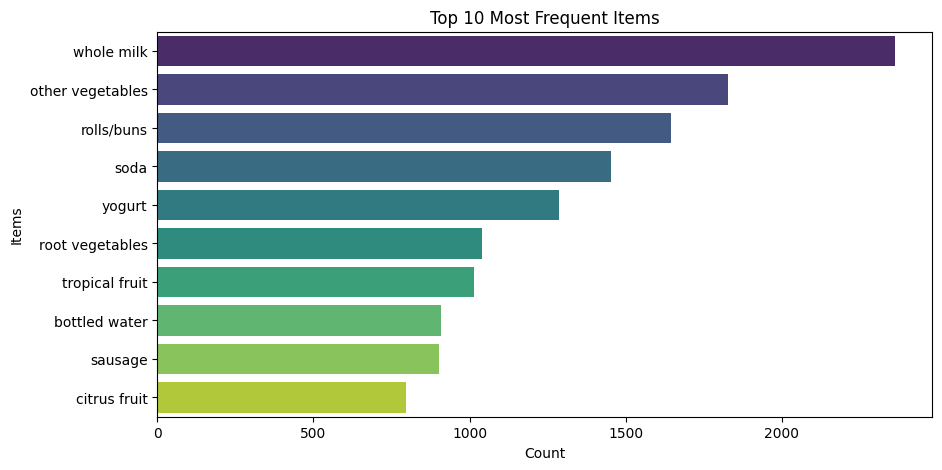

In [71]:

# Bar plot: Top 10 frequent items
top_items = Data.sum().sort_values(ascending=False).head(10) # Calculate sum of each item (True values) and get top 10
plt.figure(figsize=(10,5))
sns.barplot(x=top_items.values, y=top_items.index, palette='viridis')
plt.title("Top 10 Most Frequent Items")
plt.xlabel("Count")
plt.ylabel("Items")
plt.show()

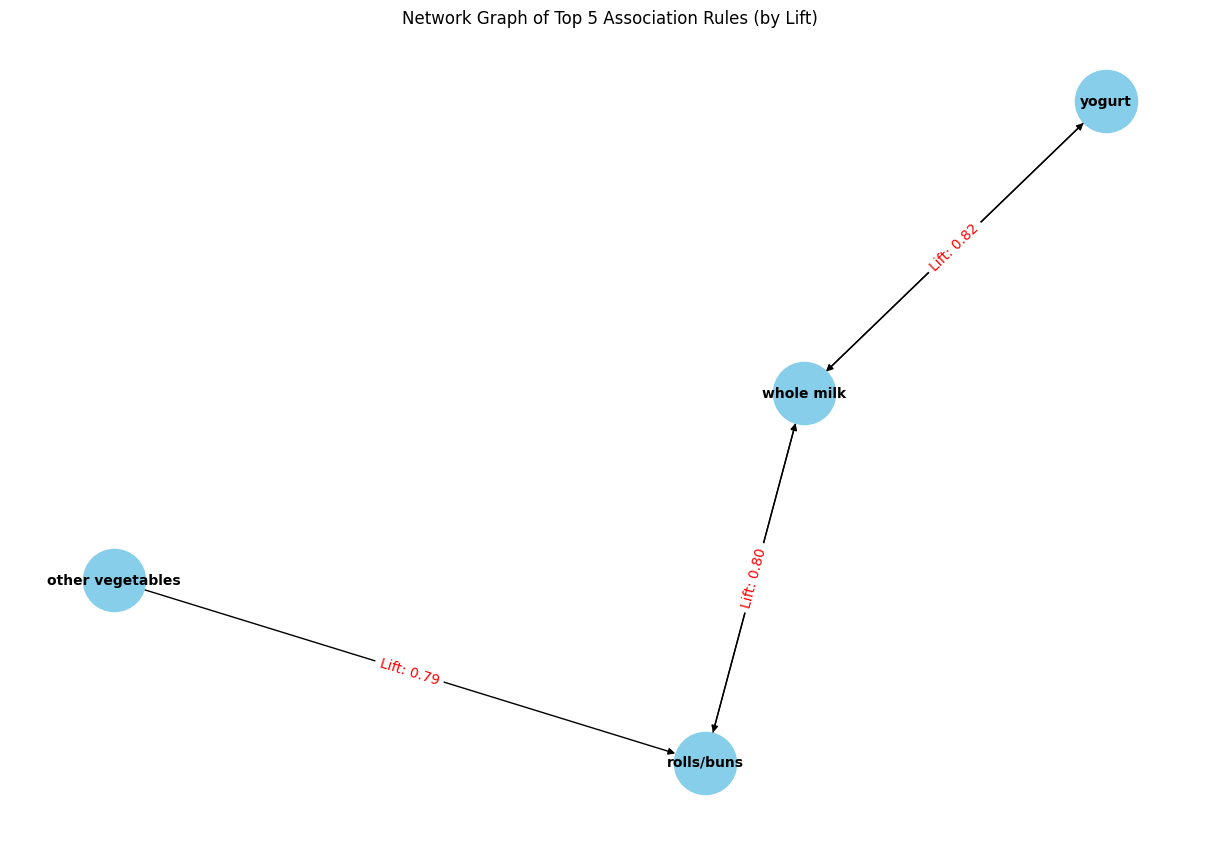

In [72]:
#
import networkx as nx
# Create graph
G = nx.DiGraph()

# Add nodes and edges from top 5 rules
for _, row in top5_rules.iterrows():
    antecedents = list(row['antecedents'])
    consequents = list(row['consequents'])
    for ant in antecedents:
        for con in consequents:
            G.add_node(ant)
            G.add_node(con)
            G.add_edge(ant, con, weight=row['lift'], label=f"Lift: {row['lift']:.2f}")

# Draw graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='skyblue', font_size=10, font_weight='bold', arrows=True)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title("Network Graph of Top 5 Association Rules (by Lift)")
plt.show()


# **Extra Credit**

In [73]:
#run apriori to get frequent itemsets
start_time = time.time()

freqitems_apriori = apriori(Data, min_support=0.01, use_colnames=True)
apriori_execution_time = time.time() - start_time
# Print the execution time
print(f"Apriori Execution Time: {apriori_execution_time:.4f} seconds")

Apriori Execution Time: 0.2313 seconds


In [74]:
import time

# APRIORI
start_ap = time.time()
freqitems_apriori = apriori(Data, min_support=0.01, use_colnames=True)
end_ap = time.time()

In [75]:
# FP-GROWTH
start_fp = time.time()
freqitems_fpgrowth = fpgrowth(Data, min_support=0.01, use_colnames=True)
end_fp = time.time()

In [76]:
 #Compare Results
print(f"Apriori - Itemsets: {freqitems_apriori.shape[0]}, Time: {end_ap - start_ap:.4f} seconds")
print(f"FP-Growth - Itemsets: {freqitems_fpgrowth.shape[0]}, Time: {end_fp - start_fp:.4f} seconds")


Apriori - Itemsets: 69, Time: 0.2290 seconds
FP-Growth - Itemsets: 69, Time: 0.3882 seconds


In [77]:
common_itemsets = pd.merge(freqitems_apriori, freqitems_fpgrowth, on='itemsets', how='inner')
print(f"Common Itemsets: {common_itemsets.shape[0]}")

Common Itemsets: 69


In [78]:
#Impact of varying Support and Confidence Thresholds on Rule Generation
# Store results
results = []

support_thresholds = [0.01, 0.02, 0.03]
confidence_thresholds = [0.3, 0.5, 0.7]

for support in support_thresholds:
    freq_items = apriori(Data, min_support=support, use_colnames=True)
    for confidence in confidence_thresholds:
        rules = association_rules(freq_items, metric='confidence', min_threshold=confidence)
        results.append({
            'Support': support,
            'Confidence': confidence,
            'Num Rules': len(rules),
            'Avg Lift': rules['lift'].mean() if not rules.empty else 0,
            'Avg Confidence': rules['confidence'].mean() if not rules.empty else 0
        })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Display table
print("Impact of Varying Support and Confidence Thresholds on Rule Generation:\n")
print(results_df)

Impact of Varying Support and Confidence Thresholds on Rule Generation:

   Support  Confidence  Num Rules  Avg Lift  Avg Confidence
0     0.01         0.3          0         0               0
1     0.01         0.5          0         0               0
2     0.01         0.7          0         0               0
3     0.02         0.3          0         0               0
4     0.02         0.5          0         0               0
5     0.02         0.7          0         0               0
6     0.03         0.3          0         0               0
7     0.03         0.5          0         0               0
8     0.03         0.7          0         0               0


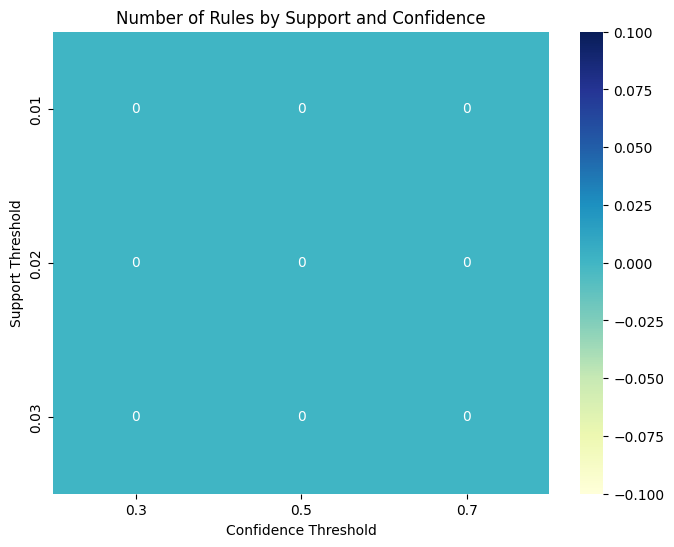

In [79]:
#Heatmap representing Number of Rules by Support and Confidence
pivot = results_df.pivot(index="Support", columns="Confidence", values="Num Rules")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Number of Rules by Support and Confidence")
plt.xlabel("Confidence Threshold")
plt.ylabel("Support Threshold")
plt.show()

In [80]:
print("📊 Promotion and Bundle Suggestions Based on Top Rules:\n")
for idx, row in top5_rules.iterrows():
    antecedent = list(row['antecedents'])
    consequent = list(row['consequents'])
    print(f"If customer buys {antecedent}, offer a deal on {consequent} (Lift: {row['lift']:.2f})")


📊 Promotion and Bundle Suggestions Based on Top Rules:

If customer buys ['whole milk'], offer a deal on ['yogurt'] (Lift: 0.82)
If customer buys ['yogurt'], offer a deal on ['whole milk'] (Lift: 0.82)
If customer buys ['whole milk'], offer a deal on ['rolls/buns'] (Lift: 0.80)
If customer buys ['rolls/buns'], offer a deal on ['whole milk'] (Lift: 0.80)
If customer buys ['other vegetables'], offer a deal on ['rolls/buns'] (Lift: 0.79)
